In [ ]:
# Install + mount
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

import numpy as np
from scipy.ndimage import sobel, gaussian_filter
from scipy import stats
import matplotlib.pyplot as plt
import os

# Copy DTM to local for fast I/O
import shutil
shutil.copy('/content/drive/MyDrive/FAIMM_CrossScale/data/orbital/hirise/mars_terrain_513x513_CLEAN.r16',
            '/content/mars_dtm.r16')
print('Ready.')

Mounted at /content/drive
Ready.


DTM shape:    (513, 513)
Elevation:    -256.0m – 256.0m
Std:          85.4m
Coverage:     2.1km × 2.1km


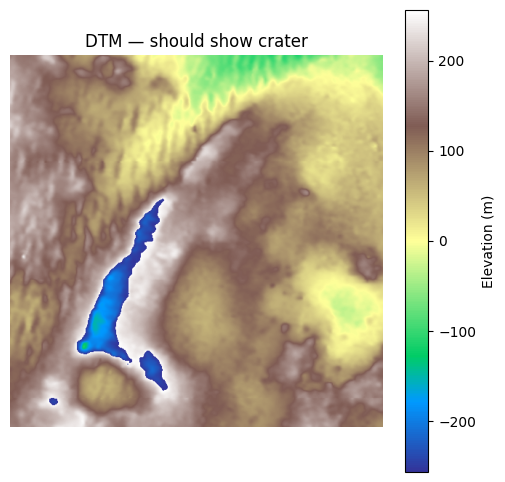

In [ ]:
import numpy as np

# Load as big-endian (correct byte order for UE R16 export)
dtm_raw = np.fromfile('/content/mars_dtm.r16',
                       dtype='>u2').reshape(513, 513).astype(np.float32)

PIXEL_SIZE_M = 4.0   # 2017px full res / 513px export × 1m/px
Z_RANGE_M    = 512.0 # Z scale=100 → ±256m

dtm_m = ((dtm_raw / 65535.0) - 0.5) * Z_RANGE_M

print(f'DTM shape:    {dtm_m.shape}')
print(f'Elevation:    {dtm_m.min():.1f}m – {dtm_m.max():.1f}m')
print(f'Std:          {dtm_m.std():.1f}m')
print(f'Coverage:     {513*PIXEL_SIZE_M/1000:.1f}km × {513*PIXEL_SIZE_M/1000:.1f}km')

# Quick sanity check — should show crater shape
import matplotlib.pyplot as plt
plt.figure(figsize=(6,6))
plt.imshow(dtm_m, cmap='terrain')
plt.colorbar(label='Elevation (m)')
plt.title('DTM — should show crater')
plt.axis('off')
plt.show()

In [ ]:
def compute_normals(dem_m, pixel_size_m=4.0):
    smooth = gaussian_filter(dem_m, sigma=1.0)
    gx = sobel(smooth, axis=1) / (8 * pixel_size_m)
    gy = sobel(smooth, axis=0) / (8 * pixel_size_m)
    nz = np.ones_like(dem_m)
    norm = np.sqrt(gx**2 + gy**2 + nz**2)
    return -gx/norm, -gy/norm, nz/norm

def synthesize(nx, ny, nz, sun_az_deg, sun_el_deg):
    az = np.radians(sun_az_deg)
    el = np.radians(sun_el_deg)
    lx = np.cos(el)*np.sin(az)
    ly = np.cos(el)*np.cos(az)
    lz = np.sin(el)
    return np.clip(nx*lx + ny*ly + nz*lz, 0, 1)

def compute_tp(nx_p, ny_p, nz_p,
               orbital_az=135, orbital_el=55,
               rover_az=45,    rover_el=25):
    """
    T(p) = cross-illumination synthesis correlation.
    Simulates orbital (high sun) vs rover (low sun, different azimuth).
    High T(p) = topographic structure stable across illumination = reliable landmark.
    """
    s_orb = synthesize(nx_p, ny_p, nz_p, orbital_az, orbital_el)
    s_rov = synthesize(nx_p, ny_p, nz_p, rover_az,   rover_el)
    s_orb_n = (s_orb - s_orb.mean()) / (s_orb.std() + 1e-8)
    s_rov_n = (s_rov - s_rov.mean()) / (s_rov.std() + 1e-8)
    return float(np.mean(s_orb_n * s_rov_n))

print('Functions defined.')

Functions defined.


In [ ]:
# Compute T(p) on dense grid over full DTM
print('Computing normals...')
nx, ny, nz = compute_normals(dtm_m, PIXEL_SIZE_M)

PATCH = 64
half  = PATCH // 2
np.random.seed(42)

results = []
for r in range(half+5, 513-half-5, 16):
    for c in range(half+5, 513-half-5, 16):
        dtm_p = dtm_m[r-half:r+half, c-half:c+half]
        nx_p  = nx[r-half:r+half, c-half:c+half]
        ny_p  = ny[r-half:r+half, c-half:c+half]
        nz_p  = nz[r-half:r+half, c-half:c+half]

        tp      = compute_tp(nx_p, ny_p, nz_p)
        dtm_std = float(dtm_p.std())
        slope   = float(np.sqrt(
            (sobel(dtm_p, axis=1)/8)**2 +
            (sobel(dtm_p, axis=0)/8)**2
        ).mean())

        results.append({
            'row': r, 'col': c,
            'tp': tp, 'dtm_std': dtm_std, 'slope': slope
        })

import pandas as pd
df = pd.DataFrame(results)
print(f'Patches evaluated: {len(df)}')
print(f'\nT(p):     mean={df.tp.mean():.3f}  std={df.tp.std():.3f}  '
      f'range={df.tp.min():.3f}–{df.tp.max():.3f}')
print(f'DTM std:  mean={df.dtm_std.mean():.2f}m  std={df.dtm_std.std():.2f}m')
print(f'Slope:    mean={df.slope.mean():.3f}  std={df.slope.std():.3f}')

print('\nCorrelations:')
for a, b in [('dtm_std','tp'), ('slope','tp'), ('dtm_std','slope')]:
    rho, p = stats.spearmanr(df[a], df[b])
    sig = '✅' if p < 0.05 else '  '
    print(f'  {sig} {a:10s} → {b:10s}  r={rho:.3f}  p={p:.3f}')

Computing normals...
Patches evaluated: 784

T(p):     mean=0.101  std=0.243  range=-0.642–0.569
DTM std:  mean=49.05m  std=54.01m
Slope:    mean=4.565  std=5.004

Correlations:
  ✅ dtm_std    → tp          r=0.310  p=0.000
  ✅ slope      → tp          r=0.460  p=0.000
  ✅ dtm_std    → slope       r=0.886  p=0.000


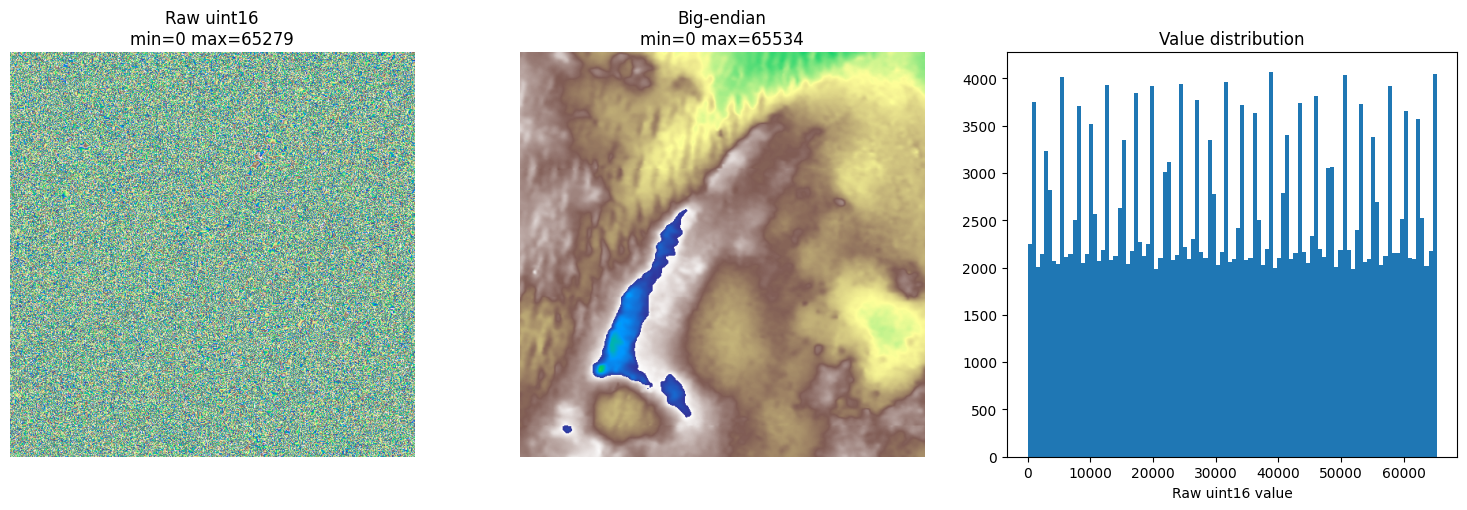

Corner values (raw):
  Top-left 5x5:
[[11983. 34512. 61649.  4307. 44755.]
 [25806. 39119. 59600. 61137. 29906.]
 [ 5838. 20687. 36560. 31953. 59089.]
 [20686. 41679. 54480. 42705. 60625.]
 [  207. 28368. 40657. 20690. 25298.]]
  Center 5x5:
[[12493. 59083. 54474. 62153. 13001.]
 [30924. 16075. 15562. 26825. 46792.]
 [37067. 30922. 40649. 62152. 24264.]
 [27850. 34505. 61640. 34504. 11464.]
 [ 7881. 30920.  8904. 64711. 60103.]]
  Value histogram (10 bins):
    0: 26445
    6528: 26818
    13056: 24885
    19584: 26599
    26112: 26682
    32640: 26850
    39167: 24817
    45695: 26646
    52223: 26561
    58751: 26866


In [ ]:
# Check what the DTM actually looks like
import numpy as np
import matplotlib.pyplot as plt

dtm_raw = np.fromfile('/content/mars_dtm.r16',
                       dtype=np.uint16).reshape(513, 513).astype(np.float32)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Raw values
axes[0].imshow(dtm_raw, cmap='terrain')
axes[0].set_title(f'Raw uint16\nmin={dtm_raw.min():.0f} max={dtm_raw.max():.0f}')
axes[0].axis('off')

# Try little-endian vs big-endian
dtm_be = np.fromfile('/content/mars_dtm.r16',
                      dtype='>u2').reshape(513, 513).astype(np.float32)
axes[1].imshow(dtm_be, cmap='terrain')
axes[1].set_title(f'Big-endian\nmin={dtm_be.min():.0f} max={dtm_be.max():.0f}')
axes[1].axis('off')

# Histogram of raw values
axes[2].hist(dtm_raw.flatten(), bins=100)
axes[2].set_title('Value distribution')
axes[2].set_xlabel('Raw uint16 value')

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/dtm_debug.png', dpi=150)
plt.show()

# Print corner values to see if there's structure
print('Corner values (raw):')
print(f'  Top-left 5x5:\n{dtm_raw[:5,:5]}')
print(f'  Center 5x5:\n{dtm_raw[254:259, 254:259]}')
print(f'  Value histogram (10 bins):')
hist, edges = np.histogram(dtm_raw, bins=10)
for h, e in zip(hist, edges):
    print(f'    {e:.0f}: {h}')

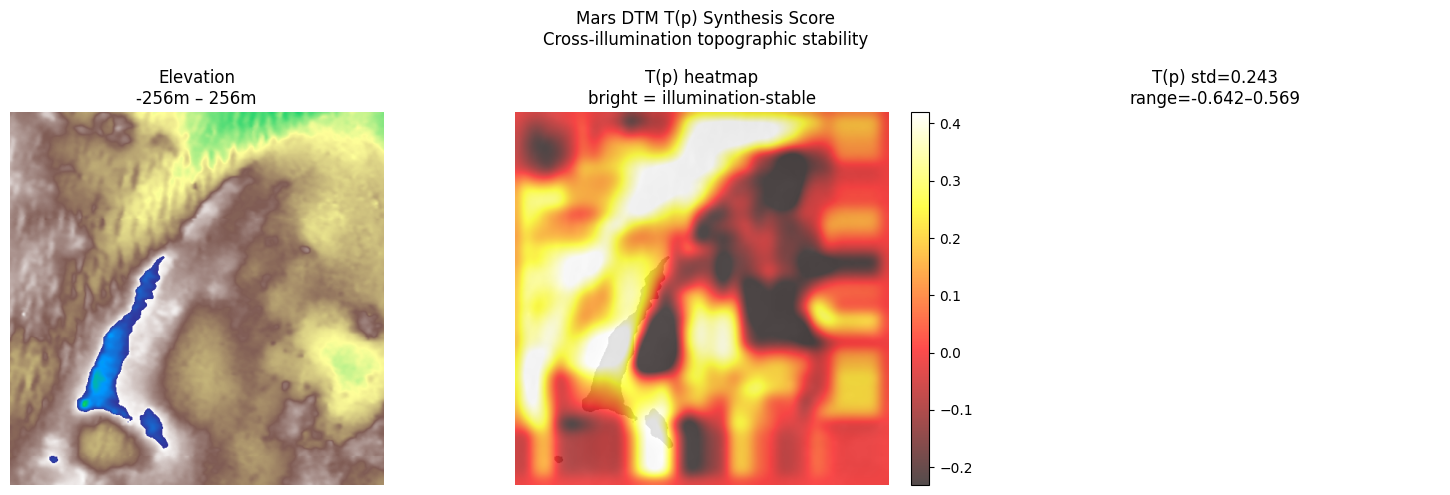

Saved.


In [ ]:
# T(p) spatial heatmap over DTM
tp_map    = np.full((513, 513), np.nan)
for _, row in df.iterrows():
    r, c = int(row.row), int(row.col)
    tp_map[r-half:r+half, c-half:c+half] = row.tp

tp_smooth = gaussian_filter(np.nan_to_num(tp_map), sigma=8)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Mars DTM T(p) Synthesis Score\n'
             'Cross-illumination topographic stability', fontsize=12)

axes[0].imshow(dtm_m, cmap='terrain')
axes[0].set_title(f'Elevation\n{dtm_m.min():.0f}m – {dtm_m.max():.0f}m')
axes[0].axis('off')

axes[1].imshow(dtm_m, cmap='gray', alpha=0.4)
im = axes[1].imshow(tp_smooth, cmap='hot', alpha=0.7,
                    vmin=np.percentile(df.tp, 10),
                    vmax=np.percentile(df.tp, 90))
axes[1].set_title('T(p) heatmap\nbright = illumination-stable')
axes[1].axis('off')
plt.colorbar(im, ax=axes[1], fraction=0.046)

# High vs low T(p) example patches
top5    = df.nlargest(5, 'tp')
bot5    = df.nsmallest(5, 'tp')
ax3     = axes[2]
ax3.axis('off')
ax3.set_title(f'T(p) std={df.tp.std():.3f}\n'
              f'range={df.tp.min():.3f}–{df.tp.max():.3f}')

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/tp_synthesis_mars_dtm.png',
            dpi=150, bbox_inches='tight')
plt.show()
print('Saved.')

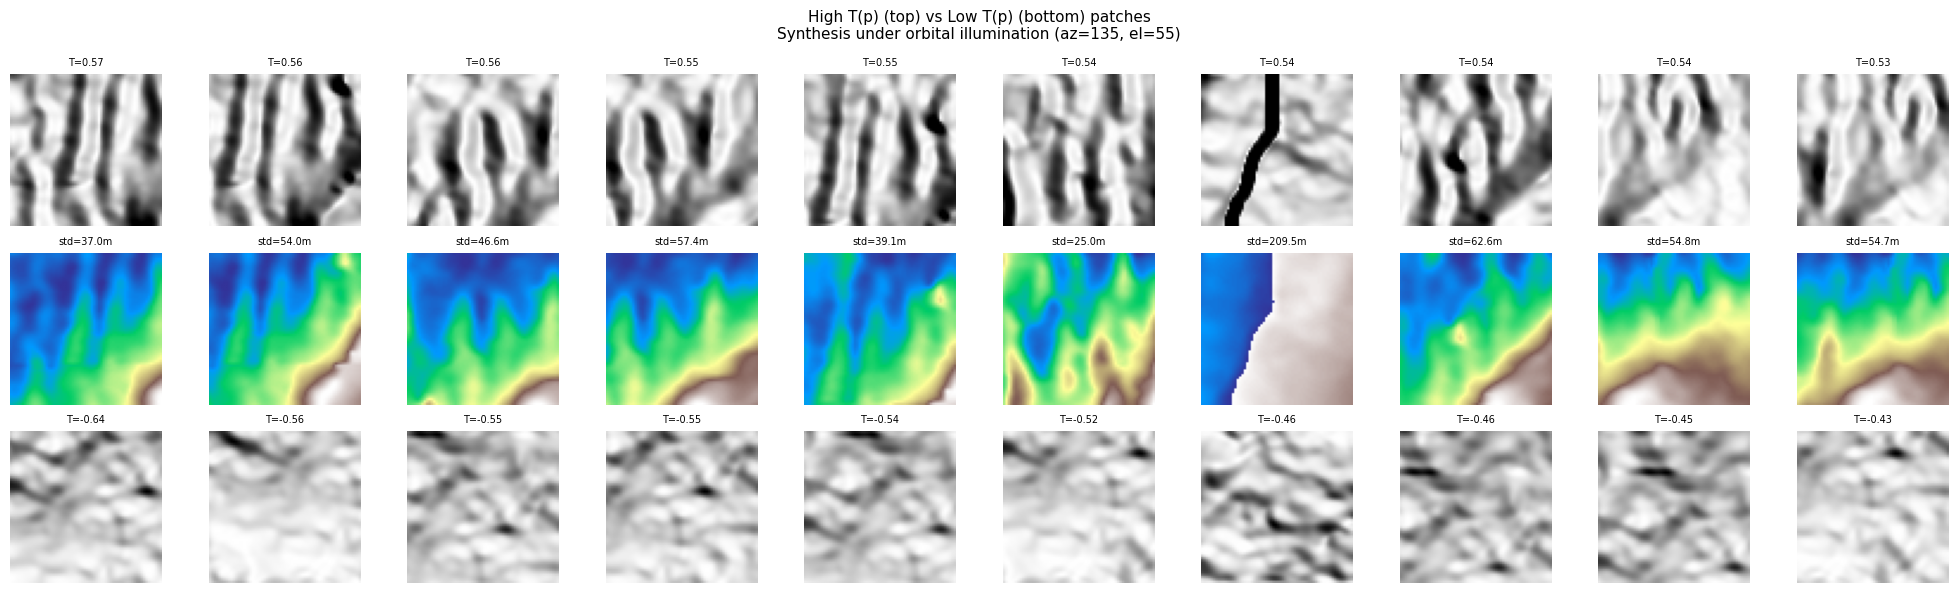

In [ ]:
# Show what high and low T(p) terrain looks like
fig, axes = plt.subplots(3, 10, figsize=(20, 6))
fig.suptitle('High T(p) (top) vs Low T(p) (bottom) patches\n'
             'Synthesis under orbital illumination (az=135, el=55)', fontsize=11)

top10 = df.nlargest(10, 'tp')
bot10 = df.nsmallest(10, 'tp')

for col, (_, row) in enumerate(top10.iterrows()):
    r, c = int(row.row), int(row.col)
    nx_p = nx[r-half:r+half, c-half:c+half]
    ny_p = ny[r-half:r+half, c-half:c+half]
    nz_p = nz[r-half:r+half, c-half:c+half]
    synth = synthesize(nx_p, ny_p, nz_p, 135, 55)
    axes[0, col].imshow(synth, cmap='gray')
    axes[0, col].set_title(f'T={row.tp:.2f}', fontsize=7)
    axes[0, col].axis('off')
    dtm_p = dtm_m[r-half:r+half, c-half:c+half]
    axes[1, col].imshow(dtm_p, cmap='terrain')
    axes[1, col].set_title(f'std={row.dtm_std:.1f}m', fontsize=7)
    axes[1, col].axis('off')

for col, (_, row) in enumerate(bot10.iterrows()):
    r, c = int(row.row), int(row.col)
    nx_p = nx[r-half:r+half, c-half:c+half]
    ny_p = ny[r-half:r+half, c-half:c+half]
    nz_p = nz[r-half:r+half, c-half:c+half]
    synth = synthesize(nx_p, ny_p, nz_p, 135, 55)
    axes[2, col].imshow(synth, cmap='gray')
    axes[2, col].set_title(f'T={row.tp:.2f}', fontsize=7)
    axes[2, col].axis('off')

axes[0, 0].set_ylabel('HIGH T(p)\nSynth', fontsize=8)
axes[1, 0].set_ylabel('HIGH T(p)\nDTM', fontsize=8)
axes[2, 0].set_ylabel('LOW T(p)\nSynth', fontsize=8)

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/tp_high_vs_low.png', dpi=150, bbox_inches='tight')
plt.show()